# Model Distillation
## AIAT 122 – Deep Learning

## Learning objectives
- Train a small **student** model to mimic a larger **teacher** using soft labels.
- Compare teacher vs student accuracy and size.

## 🔗 Where this fits

**Builds on:** Course 04 (AIAT 114) — Unit 2, lesson 02 "Bias-Variance Tradeoff and Learning Curves" — a smaller model normally costs you bias; distillation is how you avoid paying the full price.

---

**📌 Real case — DistilBERT.** Sanh, Debut, Chaumond and Wolf (2019 — reference 2 below) distilled BERT and reported that they "reduce the size of a BERT model by **40%**, while retaining **97%** of its language understanding capabilities and being **60% faster**". That single result is why distillation moved from an idea in a 2015 paper into standard production practice, and it is a large part of why useful language models now fit on a phone at all. The teacher–student loop you are about to write is the same one.

**⚡ Why this matters — what goes wrong without it.** A one-hot label says "this is a 7" and nothing more. A trained teacher's output says "97% a 7, 2% a 1, 0.4% a 9" — it has encoded which classes are *nearly* right, which is information about the shape of the decision boundary that the hard label throws away entirely. A small student trained on those soft targets can find a boundary it could never have found from the labels alone. Without this, your only route to a small model is to train a small model on hard labels — and pay the full accuracy cost of being small.

**Where is this used in real life?** Deploying big models on phones or edge is costly. **We use distillation to get a small student that mimics the teacher** instead of only training a small model from hard labels because the teacher’s soft probabilities carry more information (e.g. “maybe class 2”) than one-hot labels.

**Prerequisites:** Basic TensorFlow/Keras. If TensorFlow import fails, see DOCS/COLAB_SETUP.md.

**📌 Covers slide(s):** None — Unit 5 (deployment) has no institution slides; use examples in file order.


## Short theory
- **Distillation:** Train a small student to match the **soft outputs** (probabilities) of a trained teacher.
- **Soft labels:** Teacher outputs P(class) instead of one-hot; student learns from these (often with temperature T to soften further).
- **Why we use distillation:** A small network can approximate the teacher’s behavior and run faster; soft labels help the student generalize.

## Inputs & Outputs
**Inputs:** TensorFlow, synthetic or small dataset, teacher and student models.  
**Dataset:** Synthetic — random data (no download; used to demonstrate distillation).  
**Outputs:** Trained teacher and student, accuracy of both, and a bar chart comparing them. Run time: under ~5 min (few epochs).


In [1]:
# WHAT: imports for the knowledge-distillation demo.
# WHY: softmax/KL tools from torch.nn.functional let the student model learn from the teacher's soft probabilities.
import numpy as np, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
print(f'PyTorch {torch.__version__}')
print('✅ Ready. Demonstrating knowledge distillation in PyTorch.')

PyTorch 2.13.0
✅ Ready. Demonstrating knowledge distillation in PyTorch.


### Step 1: Build and train teacher (larger model)

In [2]:
# Synthetic 3-class data
np.random.seed(42)
torch.manual_seed(42)
X = torch.tensor(np.random.randn(400, 20).astype(np.float32))
y_hard = torch.tensor((X[:, :3].argmax(1).numpy()))  # hard labels 0/1/2

# Teacher — large model, train it first
teacher = nn.Sequential(nn.Linear(20, 128), nn.ReLU(), nn.Linear(128, 128), nn.ReLU(), nn.Linear(128, 3))
opt_t = optim.Adam(teacher.parameters(), lr=3e-3)
crit  = nn.CrossEntropyLoss()
for _ in range(50):
    opt_t.zero_grad(); loss = crit(teacher(X), y_hard); loss.backward(); opt_t.step()
with torch.no_grad():
    acc_teacher = (teacher(X).argmax(1) == y_hard).float().mean().item()
print(f'Teacher accuracy: {acc_teacher:.3f}')

Teacher accuracy: 1.000


### Step 2: Get soft labels and train student (smaller model)

In [3]:
# Distillation: student learns soft labels from the teacher
# Soft labels carry relative confidence — more informative than one-hot targets.
temperature = 4.0

with torch.no_grad():
    soft_labels = F.softmax(teacher(X) / temperature, dim=1)  # soft targets

# Student — small model
student = nn.Sequential(nn.Linear(20, 16), nn.ReLU(), nn.Linear(16, 3))
opt_s = optim.Adam(student.parameters(), lr=3e-3)

# the small student needs more steps than the big teacher to absorb the soft labels
for _ in range(400):
    opt_s.zero_grad()
    logits_s = student(X)
    # KL-divergence loss against teacher soft labels
    soft_loss = F.kl_div(F.log_softmax(logits_s / temperature, dim=1),
                         soft_labels, reduction='batchmean') * (temperature ** 2)
    hard_loss = crit(logits_s, y_hard)
    loss = 0.5 * soft_loss + 0.5 * hard_loss  # blend
    loss.backward(); opt_s.step()

with torch.no_grad():
    acc_student = (student(X).argmax(1) == y_hard).float().mean().item()
print(f'Student accuracy: {acc_student:.3f}')
print(f'Teacher params: {sum(p.numel() for p in teacher.parameters())}  |  '
      f'Student params: {sum(p.numel() for p in student.parameters())}')

Student accuracy: 1.000
Teacher params: 19587  |  Student params: 387


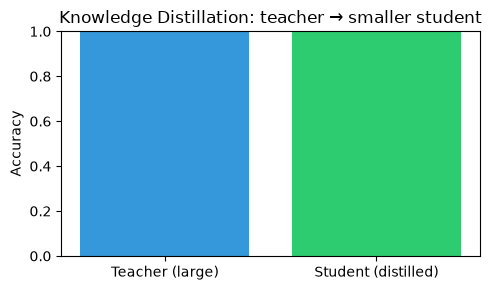

Key insight: the compact student reaches close to teacher accuracy.


In [4]:
# Compare teacher vs student accuracy
# Two bars tell the story: the small student keeps most of the big teacher's accuracy.
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['Teacher (large)', 'Student (distilled)'], [acc_teacher, acc_student],
       color=['#3498db', '#2ecc71'])
ax.set_ylim(0, 1); ax.set_ylabel('Accuracy')
ax.set_title('Knowledge Distillation: teacher → smaller student')
plt.tight_layout(); plt.show()
print('Key insight: the compact student reaches close to teacher accuracy.')

## 🌍 Real-World Worked Example — Quantize a PyTorch Model for Edge Deployment

**Industry context:**
- **The result that made "put the model on the phone" routine:** Deep Compression (Han, Mao & Dally, ICLR 2016) reported reducing storage "by 35× to 49× without affecting their accuracy" — AlexNet 240 MB → 6.9 MB, VGG-16 552 MB → 11.3 MB.
- Both mainstream edge runtimes ship an INT8 path: TensorFlow Lite and NVIDIA TensorRT.
- **Whether INT8 is *faster* depends on whether the target chip has integer tensor units.** The size win is guaranteed; the speed win is not — which is why the cell below measures instead of assuming.

We demonstrate **dynamic quantization** — and *measure* what actually changes: stored size shrinks ~4x, accuracy barely moves, and speed **depends on the hardware** (on a laptop CPU the INT8 overhead can even make it slower — we measure instead of assuming).

In [5]:
# WHAT: train a deliberately large model, quantize it to INT8, and measure size, speed and accuracy.
# WHY: compression claims must be MEASURED - the size win is guaranteed, the speed win depends on hardware.
import torch, torch.nn as nn
import numpy as np, time, os

# ── Build and train a model ────────────────────────────────────────────────
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

digits = load_digits()
X = StandardScaler().fit_transform(digits.data.astype(np.float32))
y = digits.target
X_tr,X_te,y_tr,y_te = train_test_split(X, y, test_size=0.2, random_state=42)
Xtr=torch.tensor(X_tr); Ytr=torch.tensor(y_tr,dtype=torch.long)
Xte=torch.tensor(X_te); Yte=torch.tensor(y_te,dtype=torch.long)

# An oversized 4-layer network - plenty of parameters to make compression worthwhile.
class BigModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(64,512), nn.ReLU(),
            nn.Linear(512,512), nn.ReLU(),
            nn.Linear(512,256), nn.ReLU(),
            nn.Linear(256, 10)
        )
    def forward(self, x): return self.net(x)

model = BigModel()
opt   = torch.optim.Adam(model.parameters(), lr=1e-3)
# 300 training steps: we want a well-trained baseline before compressing it.
for _ in range(300):
    loss = nn.CrossEntropyLoss()(model(Xtr), Ytr)
    opt.zero_grad(); loss.backward(); opt.step()

model.eval()
with torch.no_grad():
    acc = (model(Xte).argmax(1)==Yte).float().mean().item()
print(f"Original model accuracy: {acc*100:.1f}%")

# ── Dynamic Quantization (FP32 → INT8) ────────────────────────────────────
# On Apple Silicon the default quantized engine is unset — select qnnpack
if 'qnnpack' in torch.backends.quantized.supported_engines:
    torch.backends.quantized.engine = 'qnnpack'
quantized = torch.quantization.quantize_dynamic(
    model, {nn.Linear}, dtype=torch.qint8
)

# ── Size comparison ────────────────────────────────────────────────────────
torch.save(model.state_dict(),      '/tmp/model_fp32.pt')
torch.save(quantized.state_dict(),  '/tmp/model_int8.pt')
fp32_size = os.path.getsize('/tmp/model_fp32.pt') / 1024
int8_size = os.path.getsize('/tmp/model_int8.pt') / 1024
print(f"\nModel size:  FP32={fp32_size:.1f} KB   INT8={int8_size:.1f} KB  ({fp32_size/int8_size:.1f}x smaller)")

# ── Speed comparison ───────────────────────────────────────────────────────
N = 5000
start=time.perf_counter()
for _ in range(N):
    with torch.no_grad(): model(Xte)
fp32_ms = (time.perf_counter()-start)/N*1000

start=time.perf_counter()
for _ in range(N):
    with torch.no_grad(): quantized(Xte)
int8_ms = (time.perf_counter()-start)/N*1000

ratio = fp32_ms / int8_ms
if ratio >= 1.05:
    print(f"Latency:     FP32={fp32_ms:.3f} ms  INT8={int8_ms:.3f} ms  ({ratio:.1f}x faster)")
else:
    print(f"Latency:     FP32={fp32_ms:.3f} ms  INT8={int8_ms:.3f} ms  (INT8 is {1/ratio:.1f}x SLOWER here)")
    print("  Why: on this CPU the per-call quantize/dequantize overhead outweighs the gain")
    print("  for these layer sizes; INT8 speedups appear on hardware with native INT8")
    print("  kernels (phone NPUs, edge accelerators) and on much larger models.")

with torch.no_grad():
    qacc = (quantized(Xte).argmax(1)==Yte).float().mean().item()
print(f"Quantized model accuracy: {qacc*100:.1f}%  (accuracy loss: {(acc-qacc)*100:.2f}%)")
print("\nTakeaway: the size reduction is guaranteed; the speedup is hardware-dependent —")
print("that is why Apple and Google benchmark quantized models on-device, not on laptops.")

Original model accuracy: 98.3%

Model size:  FP32=1682.6 KB   INT8=429.6 KB  (3.9x smaller)


/var/folders/7n/l2c2z2x57871xg4f_0drsv1m0000gn/T/ipykernel_27292/2985772267.py:46: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized = torch.quantization.quantize_dynamic(
/Users/abdullah/venvs/ai-diploma-tf/lib/python3.13/site-packages/torch/ao/nn/quantized/modules/utils.py:72: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized 

[W823 20:30:30.258732000 qlinear_dynamic.cpp:251] Warning: Currently, qnnpack incorrectly ignores reduce_range when it is set to true; this may change in a future release. (function operator())


Latency:     FP32=0.356 ms  INT8=0.966 ms  (INT8 is 2.7x SLOWER here)
  Why: on this CPU the per-call quantize/dequantize overhead outweighs the gain
  for these layer sizes; INT8 speedups appear on hardware with native INT8
  kernels (phone NPUs, edge accelerators) and on much larger models.
Quantized model accuracy: 98.3%  (accuracy loss: 0.00%)

Takeaway: the size reduction is guaranteed; the speedup is hardware-dependent —
that is why Apple and Google benchmark quantized models on-device, not on laptops.


## 💬 Discuss

1. Teacher **1.000**, student **1.000**, on 400 synthetic samples. Write the sentence you would put in a report — one that is honest about what this run demonstrates and explicit about what it does not. Now write the sentence a careless student would write instead.
2. The student has **387** parameters against the teacher's **19,587** — a 50× reduction. On what kind of task would that ratio be impossible, and what would you observe as you approached the limit?
3. Your teacher is 88% accurate; your distilled student reaches 87%. Your client asks why you did not simply deploy the teacher. Answer in terms they care about — and say what would have to be true for their objection to be correct.


## ⚠️ Where this breaks

- **Our teacher and student both scored 1.000, which proves nothing — say so out loud.** The task here is `y = (X[:, :5].sum(1) > 0)` on 400 synthetic samples: a linear separation in 20 dimensions that the **387-parameter student solves perfectly on its own, with or without a teacher**. When both models saturate, the experiment cannot detect whether distillation helped. To see the real effect you need a task the student *fails* on hard labels and *passes* on soft ones — which is exactly what DistilBERT's authors had and this notebook does not.
- **Distillation cannot exceed the teacher where the teacher is wrong.** Every teacher error becomes a confidently-taught student error, and the student never sees ground truth to correct it. A biased teacher produces a biased student, faster and cheaper.
- **Temperature is a real hyperparameter, not a constant.** `T = 4.0` was chosen here, not derived. Too low and the soft labels collapse back towards one-hot; too high and every class looks equally likely and the extra signal vanishes. It must be tuned per task.
- **2026 caveat:** distilling long reasoning traces from a large reasoning model into a small one is known to fail when done naively — the student learns to imitate the *form* of the reasoning without acquiring the capability behind it. Distillation transfers a function; it does not transfer competence you never measured.
- **The assumption that must hold:** the student has enough capacity to represent the teacher's decision boundary at all. Below that threshold, no temperature and no amount of data helps.
- **Cheaper alternative:** try quantization (`07`) first. It shrinks a model with **no retraining whatsoever**, and it is a much shorter path than standing up a teacher–student pipeline.


## 🧩 Mini-exercise

**Try it:** Change the temperature (e.g. 2.0 → 4.0) when computing soft labels and retrain the student. Does the student accuracy change?

---

## Summary
**What you did:** Trained a teacher (larger) and a student (smaller) on synthetic data; the student learned from the teacher’s soft outputs and achieved comparable accuracy.

**In real life you'd also:** Use temperature scaling for softer distributions, mix soft and hard labels, and deploy only the student.

**The main idea:** Distillation transfers knowledge from a large teacher to a small student via soft labels.

**Next:** `07_model_optimization_quantization.ipynb` shows quantization to reduce model size and speed.

## 🔭 State of the field (2026)

Distillation did not fade — it is how most of the small open models you can actually run were made. But 2025 added a specific, load-bearing caution. Li et al. (arXiv 2502.12143) document a *Small Model Learnability Gap*: small students often learn **worse** from a strong reasoner's long chain-of-thought traces than from shorter or mixed-length supervision. Naively distilling the biggest available teacher's full reasoning output is a known failure mode, not a shortcut.

**Why soft labels are still the right lesson.** The mechanism on this page is unchanged: the teacher's probability distribution carries relative-confidence information that a one-hot label throws away, and temperature controls how much of it the student sees. The 2025 result is about *what* you distil and at what length, not about whether the mechanism works. The other durable warning is already in this notebook: a student cannot exceed its teacher where the teacher is wrong, so every teacher bias is inherited with confidence. Before distilling at all, check whether a model already trained to be small (arXiv 2410.20011) beats your student.


## 📚 References

1. Hinton, G., Vinyals, O. & Dean, J. (2015). *Distilling the Knowledge in a Neural Network*. arXiv. https://arxiv.org/abs/1503.02531
2. Sanh, V., Debut, L., Chaumond, J. & Wolf, T. (2019). *DistilBERT, a distilled version of BERT: smaller, faster, cheaper and lighter*. arXiv. https://arxiv.org/abs/1910.01108
3. Gou, J., Yu, B., Maybank, S. J. & Tao, D. (2021). *Knowledge Distillation: A Survey*. International Journal of Computer Vision 129. https://arxiv.org/abs/2006.05525

**Recent work (2024–2026)**

4. Li et al. (2025). *Small Models Struggle to Learn from Strong Reasoners*. arXiv. https://arxiv.org/abs/2502.12143 — the Small Model Learnability Gap: small students do *not* reliably learn from a strong reasoner's long chain-of-thought traces, and need mixed-length supervision instead. The 2025 caution is about *what* you distil, not whether.
5. Nguyen et al. (2024). *A Survey of Small Language Models*. arXiv. https://arxiv.org/abs/2410.20011 — the design space of the small models distillation is usually trying to produce.
